In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
# 상태(state) : -1.0 ~ 1.0 구간을 11개의 이산 구간으로 분할
# → Q 테이블은 표(테이블) 형태라서 정수 인덱스가 필요함
# → 연속값을 그대로 쓰면 테이블 크기가 무한대가 되므로 이산화 필요
state_space = np.linspace(-1.0, 1.0, 11)
# [-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
print(state_space)

# 행동 공간 : 좌(-1), 직진(0), 우(+1)
action_space = [-1, 0, 1]

# Q 테이블 초기화 : Q[state_index, action_index]
# shape : (11, 3)  →  상태 11개 × 행동 3개
# 각 셀 = 해당 상태에서 해당 행동을 했을 때 기대되는 누적 보상
# 초기값 0에서 시작 → 학습하면서 점점 갱신됨
q_table = np.zeros((len(state_space), len(action_space)))

[-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]


In [3]:
alpha = 0.1          # 학습률 : Q값을 얼마나 빠르게 갱신할지. 너무 크면 불안정, 너무 작으면 느림
gamma = 0.9          # 할인율 : 미래 보상의 현재 가치. 1에 가까울수록 먼 미래까지 고려
epsilon = 0.9        # 탐색률 초기값 : 초기엔 높게 설정해서 다양하게 탐색
epsilon_decay = 0.995  # 탐색률 감소율 : 에피소드마다 ε에 곱함 → 탐색↓ 활용↑
epsilon_min = 0.01   # 탐색률 하한 : 최소 1%는 항상 랜덤 행동 유지

episodes = 500       # 총 에피소드 수 (1 에피소드 = 50 스텝)

In [4]:
def get_state_index(position):
    # 현재 연속 위치값 → 가장 가까운 이산 구간의 인덱스 반환
    # np.abs(state_space - position) : 각 구간과의 거리 계산
    # np.argmin(...)                 : 거리가 가장 짧은 구간의 인덱스 반환
    return np.argmin(np.abs(state_space - position))

def get_reward(position):
    # 중앙(0.0)에 가까울수록 보상이 높음
    # 위치  0.0 → 보상  0.0 (최대)
    # 위치 ±1.0 → 보상 -1.0 (최소)
    # 보상 범위 : -1.0 ~ 0.0
    return -abs(position)

def stepFunc(position, action):
    position += action * 0.1              # 행동에 따라 위치 이동 (한 스텝 = 0.1 단위)
    position = np.clip(position, -1.0, 1.0)  # 도로 범위 벗어나지 않도록 클리핑
    reward = get_reward(position)         # 이동 후 위치에 대한 보상 계산
    return position, reward

# 동작 확인
print(get_state_index(-0.2), state_space[get_state_index(0.4)])
print(get_reward(0.5))

4 0.40000000000000013
-0.5


In [5]:
# ┌────────────────────────────────────────────────────────┐
# │              Q-Learning 전체 동작 구조                  │
# ├────────────────────────────────────────────────────────┤
# │  에피소드 시작                                          │
# │    → 임의 위치에서 출발                                 │
# │    → 50 스텝 반복                                       │
# │        ├─ 현재 위치 → 이산 상태 인덱스 변환              │
# │        ├─ ε-Greedy로 행동 선택 (탐색 or 활용)           │
# │        ├─ stepFunc() → 다음 위치 + 보상                 │
# │        ├─ Bellman 방정식으로 Q 테이블 갱신              │
# │        └─ 위치 업데이트                                 │
# │    → 에피소드 보상 저장                                 │
# │    → ε 감소                                            │
# └────────────────────────────────────────────────────────┘

reward_list = []

for ep in range(episodes):
    position = np.random.uniform(-1.0, 1.0)  # 매 에피소드마다 임의 위치에서 출발
    total_reward = 0

    for _ in range(50):
        state_idx = get_state_index(position)  # 현재 위치를 이산 상태 인덱스로 변환

        # ── ε-Greedy 탐색 전략 ────────────────────────────────────
        # 탐색(Exploration) : 무작위 행동 → 새로운 전략 발견 가능
        # 활용(Exploitation) : Q값 최대 행동 → 지금까지 배운 최선 선택
        if random.random() < epsilon:
            action_idx = random.choice([0, 1, 2])       # 탐색
        else:
            action_idx = np.argmax(q_table[state_idx])  # 활용

        action = action_space[action_idx]
        next_position, reward = stepFunc(position, action)
        next_state_idx = get_state_index(next_position)

        # ── Q 테이블 갱신 (Bellman Equation) ─────────────────────
        # Q(s,a) ← Q(s,a) + α * [ r + γ * max Q(s',a') - Q(s,a) ]
        #
        # r + γ * max Q(s',a')  : TD 타깃 (정답 레이블 역할)
        # TD 타깃 - Q(s,a)      : TD 오차 (현재 예측과 타깃의 차이)
        # α * TD 오차           : Q값을 타깃 방향으로 조금씩 이동
        best_next_q = np.max(q_table[next_state_idx])
        q_table[state_idx, action_idx] += alpha * (
            reward + gamma * best_next_q - q_table[state_idx, action_idx]
        )

        position = next_position
        total_reward += reward

    reward_list.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)  # ε 감소

    # 50 에피소드마다 성능 출력
    if ep % 50 == 0:
        initial_avg = np.mean(reward_list[:50])
        final_avg   = np.mean(reward_list[-50:])
        print(f'===== Episode {ep + 1} =====')
        print(f'  initial 50 avg  : {initial_avg:.3f}')
        print(f'  recent  50 avg  : {final_avg:.3f}')
        print(f'  best / worst    : {np.max(reward_list):.3f} / {np.min(reward_list):.3f}')
        if final_avg > initial_avg:
            print(f'  → 개선됨 (+{final_avg - initial_avg:.3f})\n')
        else:
            print('  → 크게 개선되지 않음\n')

===== Episode 1 =====
  initial 50 avg  : -24.651
  recent  50 avg  : -24.651
  best / worst    : -24.651 / -24.651
  → 크게 개선되지 않음

===== Episode 51 =====
  initial 50 avg  : -17.045
  recent  50 avg  : -16.943
  best / worst    : -4.708 / -46.313
  → 개선됨 (+0.102)

===== Episode 101 =====
  initial 50 avg  : -17.045
  recent  50 avg  : -8.920
  best / worst    : -3.503 / -46.313
  → 개선됨 (+8.125)

===== Episode 151 =====
  initial 50 avg  : -17.045
  recent  50 avg  : -6.739
  best / worst    : -2.870 / -46.313
  → 개선됨 (+10.306)

===== Episode 201 =====
  initial 50 avg  : -17.045
  recent  50 avg  : -6.202
  best / worst    : -2.461 / -46.313
  → 개선됨 (+10.843)

===== Episode 251 =====
  initial 50 avg  : -17.045
  recent  50 avg  : -4.754
  best / worst    : -0.900 / -46.313
  → 개선됨 (+12.291)

===== Episode 301 =====
  initial 50 avg  : -17.045
  recent  50 avg  : -4.561
  best / worst    : -0.900 / -46.313
  → 개선됨 (+12.484)

===== Episode 351 =====
  initial 50 avg  : -17.045
  recent

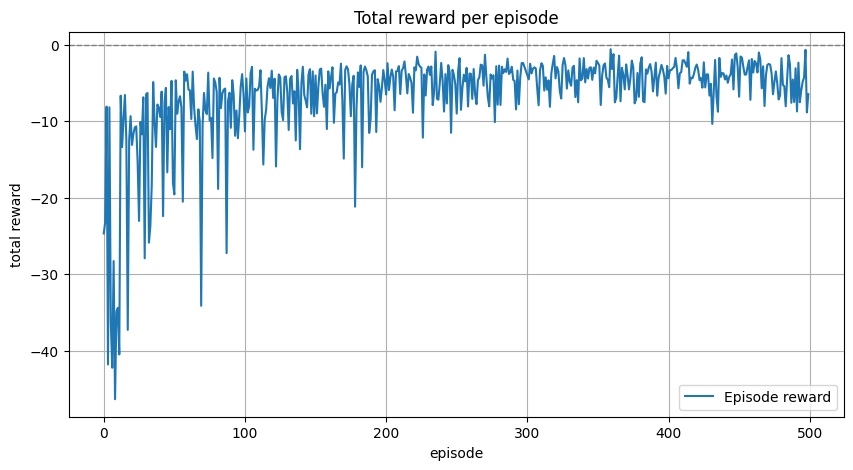

In [6]:
# 학습이 잘 되면 보상이 0에 가까워지는 방향으로 상승해야 함
# 초반(ep 0~100) : 탐색 위주라 진폭이 크고 불안정
# 후반(ep 300~) : 활용 위주로 전환되며 안정화
plt.figure(figsize=(10, 5))
plt.plot(reward_list, label='Episode reward')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('episode')
plt.ylabel('total reward')
plt.title('Total reward per episode')
plt.grid(True)
plt.legend()
plt.show()

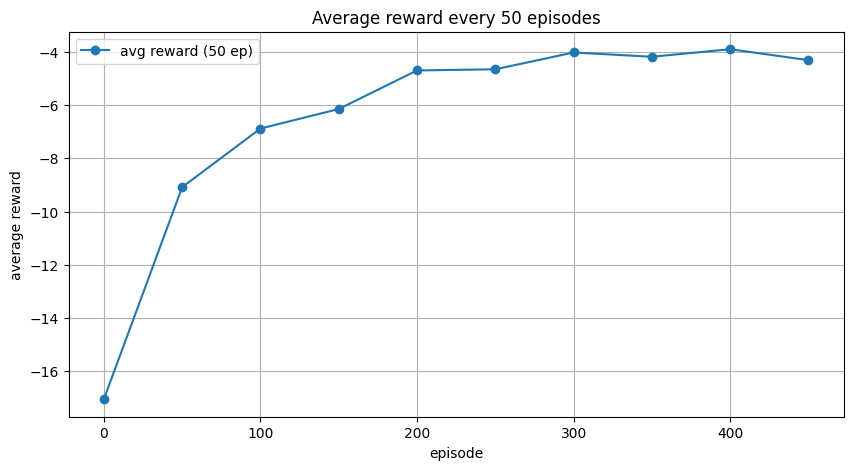

In [7]:
# 노이즈가 많은 원본 보상 곡선을 50 에피소드 구간 평균으로 부드럽게 시각화
# 전체적인 학습 트렌드(개선 여부) 파악에 유리
# ep 0 → -17 수준에서 ep 300 이후 → -4 수준으로 수렴 : 학습 성공
window = 50
avg_rewards = [np.mean(reward_list[i:i+window]) for i in range(0, len(reward_list), window)]

plt.figure(figsize=(10, 5))
plt.plot(range(0, len(reward_list), window), avg_rewards, marker='o', label='avg reward (50 ep)')
plt.xlabel('episode')
plt.ylabel('average reward')
plt.title('Average reward every 50 episodes')
plt.grid(True)
plt.legend()
plt.show()

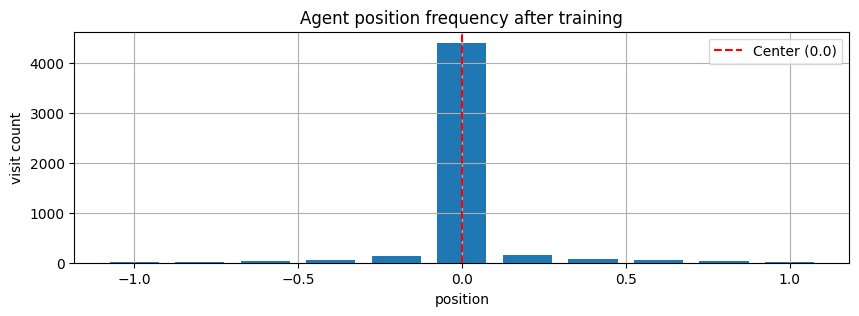

In [8]:
# 학습 완료 후 에이전트가 각 위치 구간에 얼마나 자주 방문했는지 시각화
# 중앙(0.0) 막대가 압도적으로 높으면 → 에이전트가 중앙 유지 전략을 학습한 것
position_counts = np.zeros(len(state_space))

for _ in range(100):
    position = np.random.uniform(-1.0, 1.0)
    for _ in range(50):
        state_idx = get_state_index(position)
        position_counts[state_idx] += 1  # 해당 상태 방문 횟수 누적

        if np.random.rand() < epsilon:
            action_idx = np.random.choice(len(action_space))  # 탐색
        else:
            action_idx = np.argmax(q_table[state_idx])        # 활용

        action = action_space[action_idx]
        position, _ = stepFunc(position, action)

plt.figure(figsize=(10, 3))
plt.bar(state_space, position_counts, width=0.15, align='center')
plt.xlabel('position')
plt.ylabel('visit count')
plt.title('Agent position frequency after training')
plt.axvline(0, color='red', linestyle='--', label='Center (0.0)')
plt.grid(True)
plt.legend()
plt.show()